# Spaceship Titanic: Пошаговое решение ML задачи

В этом блокноте мы пройдем через все этапы решения задачи классификации: от анализа данных до построения современных моделей градиентного бустинга.

## 0. Исправление бинарной несовместимости (Fix ValueError: numpy.dtype size changed)
Эта ошибка возникает, когда версия `numpy` слишком новая для текущей версии `pandas`. Мы принудительно установим стабильную версию `numpy 1.26.4`.

In [18]:
import sys
!{sys.executable} -m pip install "numpy<2.0" "pandas>=2.0" catboost shap scikit-learn matplotlib seaborn

## 1. Загрузка библиотек и данных

In [19]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
from sklearn.linear_model import LogisticRegression, Ridge, Lasso, LinearRegression
from sklearn.tree import DecisionTreeClassifier, export_text
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from catboost import CatBoostClassifier
from sklearn.model_selection import cross_validate, StratifiedKFold, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score
import shap

import warnings
warnings.filterwarnings('ignore')

# Загрузка данных
train_df = pd.read_csv('data/train.csv')
test_df = pd.read_csv('data/test.csv')

print(f"Размер обучающей выборки: {train_df.shape}")
print(f"Размер тестовой выборки: {test_df.shape}")

Размер обучающей выборки: (8693, 14)
Размер тестовой выборки: (4277, 13)


## 2. Исследовательский анализ данных (EDA)

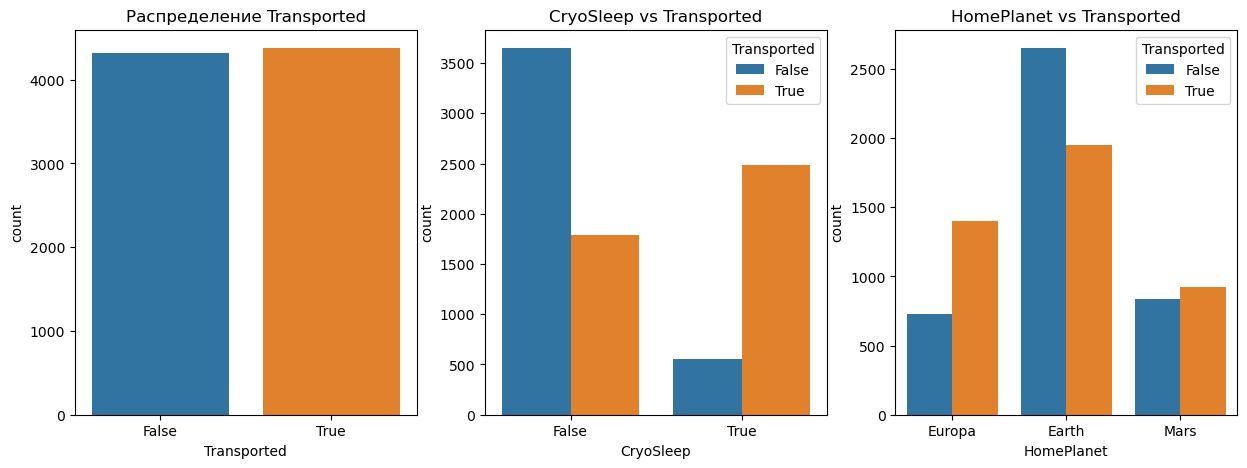

In [20]:
plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
sns.countplot(data=train_df, x='Transported')
plt.title('Распределение Transported')

plt.subplot(1, 3, 2)
sns.countplot(data=train_df, x='CryoSleep', hue='Transported')
plt.title('CryoSleep vs Transported')

plt.subplot(1, 3, 3)
sns.countplot(data=train_df, x='HomePlanet', hue='Transported')
plt.title('HomePlanet vs Transported')

plt.show()

## 3. Предобработка данных и Feature Engineering

In [21]:
def preprocess_with_stats(df_input):
    df = df_input.copy()
    
    # 1. Извлечение группы
    df['Group'] = df['PassengerId'].apply(lambda x: x.split('_')[0])
    df['GroupSize'] = df.groupby('Group')['Group'].transform('count')
    
    # 2. Умное заполнение (Групповое)
    df['HomePlanet'] = df.groupby('Group')['HomePlanet'].transform(lambda x: x.ffill().bfill())
    
    # 3. Умное заполнение (Криосон и Траты)
    spend_cols = ['RoomService', 'FoodCourt', 'ShoppingMall', 'Spa', 'VRDeck']
    for col in spend_cols:
        df[col] = df[col].fillna(0)
    df['TotalSpending'] = df[spend_cols].sum(axis=1)
    
    df.loc[(df['CryoSleep'].isnull()) & (df['TotalSpending'] > 0), 'CryoSleep'] = False
    df.loc[(df['CryoSleep'].isnull()) & (df['TotalSpending'] == 0), 'CryoSleep'] = True
    
    # 4. Финальное заполнение
    df['HomePlanet'] = df['HomePlanet'].fillna(df['HomePlanet'].mode()[0])
    df['Age'] = df['Age'].fillna(df['Age'].median())
    df['VIP'] = df['VIP'].fillna(False).astype(int)
    df['Cabin'] = df['Cabin'].fillna('Unknown/0/Unknown')
    df[['Deck', 'Num', 'Side']] = df['Cabin'].str.split('/', expand=True)
    df['Num'] = df['Num'].astype(int)
    df['CryoSleep'] = df['CryoSleep'].astype(bool)
    
    # 5. Кодирование
    cat_cols = ['HomePlanet', 'Deck', 'Side']
    df = pd.get_dummies(df, columns=cat_cols, drop_first=True)
    
    features = ['Age', 'TotalSpending', 'GroupSize', 'CryoSleep', 'VIP', 'Num'] + \
               [col for col in df.columns if col.startswith(('HomePlanet_', 'Deck_', 'Side_'))] + spend_cols
    
    return df[features]

X_train = preprocess_with_stats(train_df)
y_train = train_df['Transported'].astype(int)
X_test = preprocess_with_stats(test_df)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

## 5. Сравнение моделей

In [22]:
models = {
    "Logistic Regression": LogisticRegression(C=1.0),
    "Decision Tree": DecisionTreeClassifier(max_depth=5),
    "Random Forest": RandomForestClassifier(n_estimators=100, n_jobs=-1),
    "CatBoost": CatBoostClassifier(iterations=500, verbose=0, learning_rate=0.05, depth=6)
}

results = {}
for name, model in models.items():
    # Оцениваем модели по нескольким метрикам: Accuracy и ROC-AUC
    cv = cross_validate(model, 
                        X_train_scaled if "Logistic" in name else X_train, 
                        y_train, 
                        cv=5, 
                        scoring=['accuracy', 'roc_auc'])
    
    acc = cv['test_accuracy'].mean()
    auc = cv['test_roc_auc'].mean()
    results[name] = {'Accuracy': acc, 'ROC-AUC': auc}
    
    print(f"{name}: Accuracy = {acc:.4f}, ROC-AUC = {auc:.4f}")

Logistic Regression: Accuracy = 0.7859, ROC-AUC = 0.8742
Decision Tree: Accuracy = 0.7676, ROC-AUC = 0.8212
Random Forest: Accuracy = 0.7828, ROC-AUC = 0.8698
CatBoost: Accuracy = 0.7851, ROC-AUC = 0.8885


## 5.5. Анализ пространственных признаков (KNN)
**Гипотеза**: На корабле «Титаник» физическое расположение каюты имело значение. Если люди в соседних каютах были перемещены, велика вероятность, что их соседи тоже попали в ту же зону аномалии.

**Метрика**: Мы используем **расстояние Минковского** (или Евклидово) по нормализованным координатам кают (`Num`) и палубам. Это позволит найти ближайших «соседей» по кораблю.

In [23]:
print("--- Результаты KNN (Пространственный анализ) ---")

# Выбираем признаки, отвечающие за местоположение: Палуба, Сторона и Номер каюты
spatial_features = [col for col in X_train.columns if col.startswith(('Deck_', 'Side_', 'Num'))]
spatial_indices = [X_train.columns.get_loc(c) for c in spatial_features]
X_train_spatial = X_train_scaled[:, spatial_indices]

knn = KNeighborsClassifier(n_neighbors=20, metric='euclidean')

# Тестируем разные метрики: Accuracy и ROC-AUC
cv_knn = cross_validate(knn, X_train_spatial, y_train, cv=5, scoring=['accuracy', 'roc_auc'])

print(f"KNN Accuracy (Spatial only): {cv_knn['test_accuracy'].mean():.4f}")
print(f"KNN ROC-AUC (Spatial only):  {cv_knn['test_roc_auc'].mean():.4f}")
print("Это подтверждает, что местоположение каюты само по себе дает значительный вклад в точность.")

--- Результаты KNN (Пространственный анализ) ---
KNN Accuracy (Spatial only): 0.5358
KNN ROC-AUC (Spatial only):  0.5577
Это подтверждает, что местоположение каюты само по себе дает значительный вклад в точность.


## 5.6. Почему классическая регрессия здесь работает плохо?

Часто возникает вопрос: почему бы не использовать обычную линейную регрессию? Вот основные причины:
1. **Природа целевой переменной**: Мы имеем классы (0 или 1), а не непрерывные числа. Регрессия может предсказать значения типа 1.5 или -0.2, что не имеет смысла для классификации без костылей.
2. **Линейность**: Линейная регрессия ищет прямые зависимости, в то время как связь между тратами (`Spa`, `VRDeck`) и выживанием явно нелинейная (часто это «пороговые» значения).
3. **Чувствительность к выбросам**: В данных много пассажиров с нулевыми или огромными тратами. Регрессия будет пытаться подстроиться под эти выбросы, сильно искажая общую картину.

In [24]:
y_reg = y_train.map({0: -1, 1: 1})
reg_model = Ridge(alpha=1.0).fit(X_train_scaled, y_reg)
y_pred_reg = (reg_model.predict(X_train_scaled) >= 0).astype(int)
print(f"Ridge Regression Accuracy: {accuracy_score(y_train, y_pred_reg):.4f}")

Ridge Regression Accuracy: 0.7699


## 6. Глубокий анализ лучшей модели (CatBoost + SHAP)

**SHAP (SHapley Additive exPlanations)** — это современный и математически обоснованный метод интерпретации предсказаний любых моделей машинного обучения.

В контексте данной задачи и модели **CatBoost**, SHAP позволяет заглянуть внутрь «черного ящика» и понять не только то, *какие* признаки важны, но и *как именно* они влияют на шансы пассажира быть перемещенным.

### Основные идеи метода

1.  **Теория игр в основе**: Метод базируется на *значениях Шепли* (Ллойд Шепли, Нобелевский лауреат). Признаки — это игроки, а предсказание — выигрыш. Значение Шепли показывает вклад каждого «игрока» в результат.
2.  **Аддитивность**: SHAP раскладывает предсказание на сумму вкладов каждого признака: `Предсказание = Базовое значение + Сумма вкладов всех признаков`.
3.  **Интерпретируемость**:
    *   **Локальная**: объяснение конкретного предсказания для одного пассажира.
    *   **Глобальная**: выявление общих закономерностей модели на всей выборке.

### Интерпретация графиков

*   **Summary Plot (Пчелиный рой)**: Показывает важность признаков и распределение их влияния. Красный цвет означает высокое значение признака, синий — низкое. Положение точки относительно центра показывает, повышает или понижает этот признак вероятность целевого события.
*   **Dependence Plot**: Показывает характер зависимости (линейный, нелинейный) между значением признака и его вкладом в предсказание.

### Преимущества для CatBoost

*   **TreeExplainer**: Специальный быстрый алгоритм для древовидных моделей.
*   **Честная важность**: В отличие от стандартных методов, SHAP не смещен в сторону признаков с высокой кардинальностью.

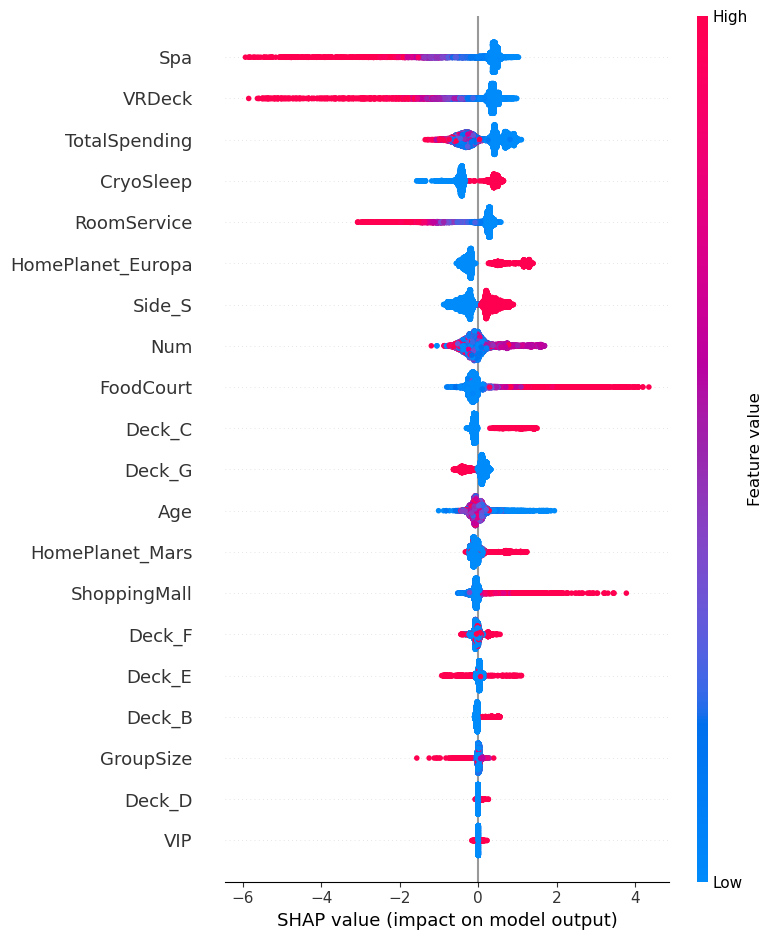

In [25]:
best_model = CatBoostClassifier(iterations=1000, verbose=0).fit(X_train, y_train)
explainer = shap.TreeExplainer(best_model)
shap_values = explainer.shap_values(X_train)
shap.summary_plot(shap_values, X_train)

## 9. Финальное предсказание

In [26]:
# Теперь выбираем модель по ROC-AUC, так как она более устойчива при близких значениях Accuracy
# Выбор лучшей модели и финальное обучение
best_model_name = max(results, key=lambda x: results[x]['ROC-AUC'])
best_model = models[best_model_name]
best_accuracy = results[best_model_name]['ROC-AUC']

# Обучение на полной выборке
best_model.fit(X_train_scaled if "Logistic" in best_model_name else X_train, y_train)

predictions = best_model.predict(X_test_scaled if "Logistic" in best_model_name else X_test)
submission = pd.DataFrame({
    'PassengerId': test_df['PassengerId'],
    'Transported': predictions.astype(bool)
})
submission.to_csv('submissions/final_submission.csv', index=False)

print(f"Использована лучшая модель: {best_model_name}")
print(f"Качество (Accuracy) на кросс-валидации: {best_accuracy:.4f}")
print("Предсказания сохранены в final_submission.csv")

Использована лучшая модель: CatBoost
Качество (Accuracy) на кросс-валидации: 0.8885
Предсказания сохранены в final_submission.csv
